In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
##Load the data

In [4]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')
gender_submission_df = pd.read_csv('/content/gender_submission.csv')

In [5]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


In [6]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
##Finding the null values

In [9]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
##Filling the Age column with median value

In [11]:
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

<ipython-input-11-3c86c38e598e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)


In [12]:
##Dropping the Cabin column due to too many missing values

In [13]:
train_df.drop('Cabin', axis=1, inplace=True)


In [14]:
##Filling the Embarked column with most common value

In [15]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)


<ipython-input-15-0be6a0f72384>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)


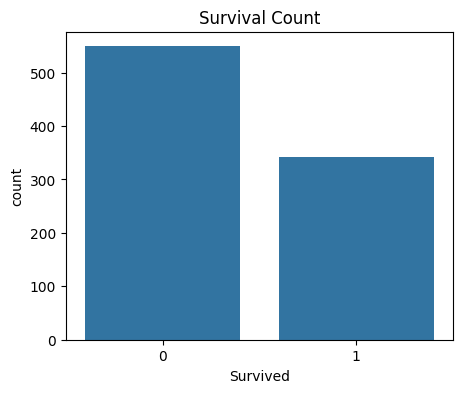

In [19]:
# 5. Univariate Analysis

# Survived count plot
plt.figure(figsize=(5, 4))
sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count")
plt.show()

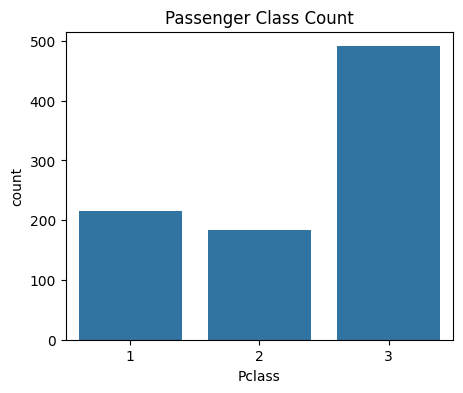

In [20]:
# Pclass count plot
plt.figure(figsize=(5, 4))
sns.countplot(x='Pclass', data=train_df)
plt.title("Passenger Class Count")
plt.show()

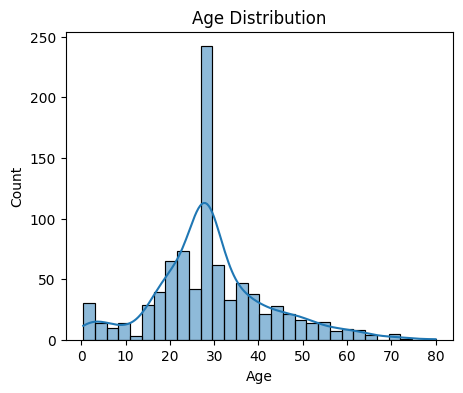

In [23]:
# Age distribution
plt.figure(figsize=(5, 4))
sns.histplot(train_df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

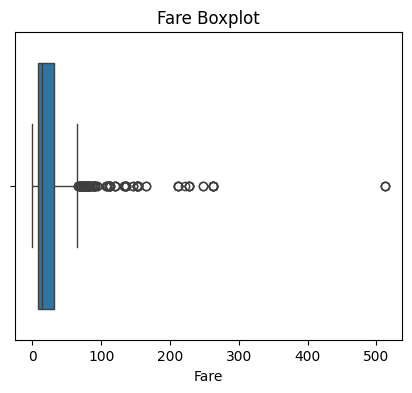

In [24]:
# Fare distribution
plt.figure(figsize=(5, 4))
sns.boxplot(x=train_df['Fare'])
plt.title("Fare Boxplot")
plt.show()

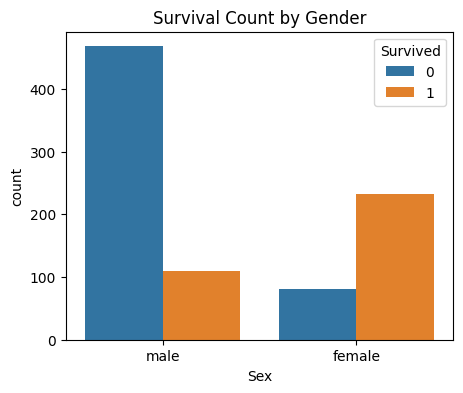

In [28]:
# 6. Bivariate Analysis
# Survival by Sex
plt.figure(figsize=(5, 4))
sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.title("Survival Count by Gender")
plt.show()

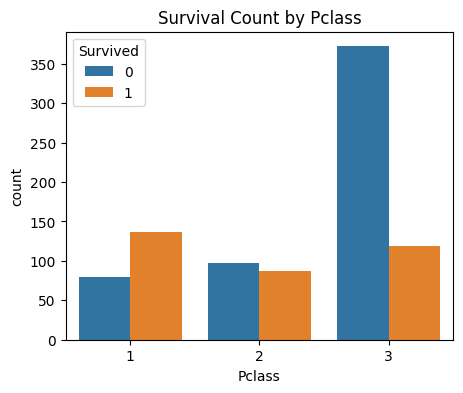

In [29]:
# Survival by Pclass
plt.figure(figsize=(5, 4))
sns.countplot(x='Pclass', hue='Survived', data=train_df)
plt.title("Survival Count by Pclass")
plt.show()


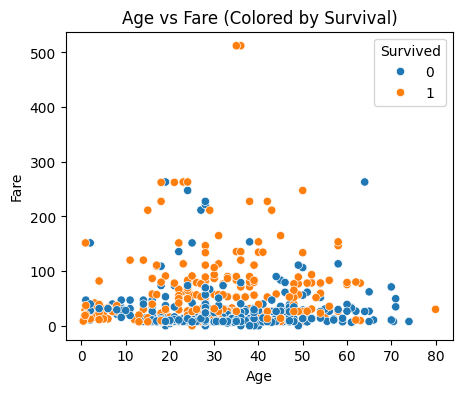

In [30]:
# Age vs Fare scatter
plt.figure(figsize=(5, 4))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train_df)
plt.title("Age vs Fare (Colored by Survival)")
plt.show()


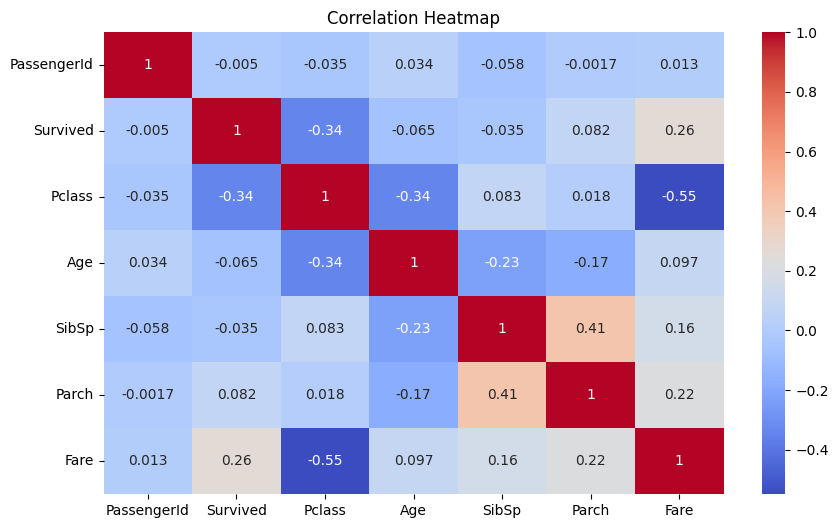

In [33]:
# 7. Multivariate Analysis

# Select only numeric columns
numeric_df = train_df.select_dtypes(include=['number'])

# Heatmap of correlations between numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


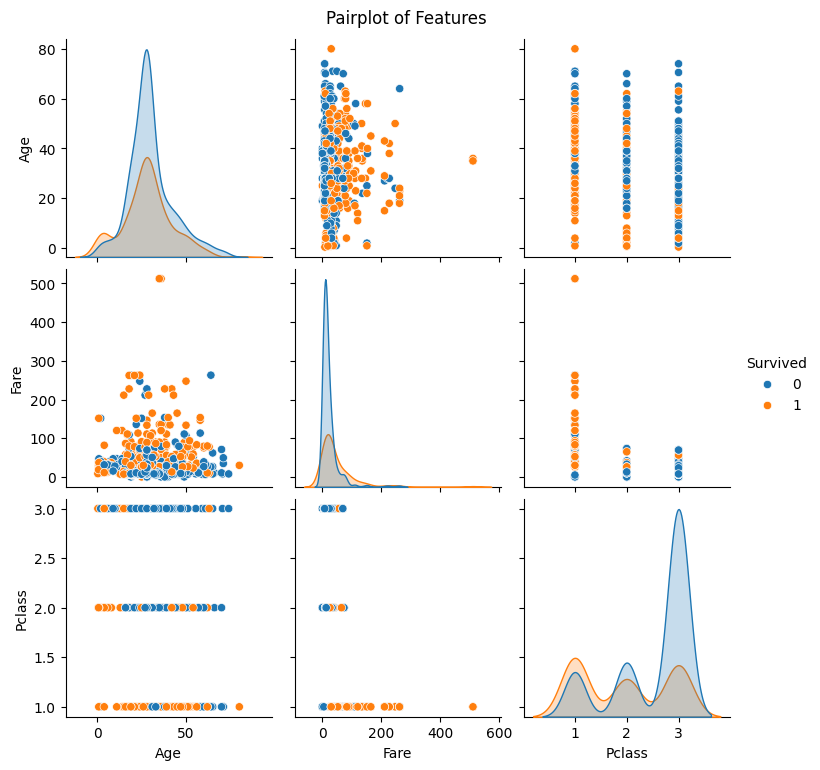

In [32]:
# Pairplot (on selected numerical features)
sns.pairplot(train_df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived')
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()

In [34]:
# 8. Summary of Findings
summary = """
Summary of Key Insights:
1. Females had a higher survival rate than males.
2. Passengers in 1st class had the highest survival rate.
3. Younger passengers had slightly better chances of survival.
4. High fare-paying passengers were more likely to survive.
5. Age and Fare are moderately correlated; most other features are weakly correlated.
"""
print(summary)



Summary of Key Insights:
1. Females had a higher survival rate than males.
2. Passengers in 1st class had the highest survival rate.
3. Younger passengers had slightly better chances of survival.
4. High fare-paying passengers were more likely to survive.
5. Age and Fare are moderately correlated; most other features are weakly correlated.

